# 2D Frame Structural Analysis
### Direct Stiffness Method
This notebook implements a 2D frame analysis using the direct stiffness method.  
Each element has 3 DOFs per node: **horizontal (u), vertical (v), rotation (θ)**

## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

np.set_printoptions(precision=4, suppress=True)

## 2. Element Stiffness Matrix
For a 2D frame element, the local stiffness matrix (6x6) combines axial and bending stiffness.

In [2]:
def local_stiffness(E, A, I, L):
    """
    Compute the 6x6 local stiffness matrix for a 2D frame element.
    
    Parameters:
        E : Elastic modulus
        A : Cross-sectional area
        I : Second moment of area
        L : Element length
    
    DOF order: [u1, v1, θ1, u2, v2, θ2]
    """
    EA = E * A / L
    EI = E * I
    
    k = np.zeros((6, 6))
    
    # Axial terms
    k[0, 0] =  EA
    k[0, 3] = -EA
    k[3, 0] = -EA
    k[3, 3] =  EA
    
    # Bending terms
    k[1, 1] =  12*EI/L**3
    k[1, 2] =   6*EI/L**2
    k[1, 4] = -12*EI/L**3
    k[1, 5] =   6*EI/L**2
    
    k[2, 1] =   6*EI/L**2
    k[2, 2] =   4*EI/L
    k[2, 4] =  -6*EI/L**2
    k[2, 5] =   2*EI/L
    
    k[4, 1] = -12*EI/L**3
    k[4, 2] =  -6*EI/L**2
    k[4, 4] =  12*EI/L**3
    k[4, 5] =  -6*EI/L**2
    
    k[5, 1] =   6*EI/L**2
    k[5, 2] =   2*EI/L
    k[5, 4] =  -6*EI/L**2
    k[5, 5] =   4*EI/L
    
    return k

## 3. Transformation Matrix
Transforms from local to global coordinates using the element's angle.

In [3]:
def transformation_matrix(angle_deg):
    """
    Compute the 6x6 transformation matrix T for a frame element.
    
    Parameters:
        angle_deg : Angle of the element from horizontal (degrees)
    """
    a = np.radians(angle_deg)
    c = np.cos(a)
    s = np.sin(a)
    
    T = np.zeros((6, 6))
    for i in range(2):
        row = i * 3
        T[row,   row]   =  c
        T[row,   row+1] =  s
        T[row+1, row]   = -s
        T[row+1, row+1] =  c
        T[row+2, row+2] =  1.0
    return T


def global_stiffness_element(E, A, I, node_i, node_j):
    """
    Compute the global 6x6 stiffness matrix for one element.
    
    Parameters:
        E, A, I   : Material and section properties
        node_i    : (x, y) coordinates of start node
        node_j    : (x, y) coordinates of end node
    """
    dx = node_j[0] - node_i[0]
    dy = node_j[1] - node_i[1]
    L  = np.sqrt(dx**2 + dy**2)
    angle = np.degrees(np.arctan2(dy, dx))
    
    k_local = local_stiffness(E, A, I, L)
    T       = transformation_matrix(angle)
    k_global = T.T @ k_local @ T
    
    return k_global, L, angle

## 4. Assemble Global Stiffness Matrix

In [4]:
def assemble_global_K(nodes, elements):
    """
    Assemble the global stiffness matrix for the entire frame.
    
    Parameters:
        nodes    : dict {node_id: (x, y)}
        elements : list of dicts with keys:
                   'nodes': (i, j), 'E': float, 'A': float, 'I': float
    
    Returns:
        K_global : (3n x 3n) global stiffness matrix
    """
    n_nodes = len(nodes)
    n_dof   = 3 * n_nodes
    K       = np.zeros((n_dof, n_dof))
    
    node_ids = list(nodes.keys())
    
    for elem in elements:
        ni, nj = elem['nodes']
        xi, yi = nodes[ni]
        xj, yj = nodes[nj]
        
        k_e, L, angle = global_stiffness_element(
            elem['E'], elem['A'], elem['I'],
            (xi, yi), (xj, yj)
        )
        elem['L']     = L
        elem['angle'] = angle
        
        # Global DOF indices for this element
        idx_i = node_ids.index(ni) * 3
        idx_j = node_ids.index(nj) * 3
        dofs  = [idx_i, idx_i+1, idx_i+2, idx_j, idx_j+1, idx_j+2]
        
        for a in range(6):
            for b in range(6):
                K[dofs[a], dofs[b]] += k_e[a, b]
    
    return K

## 5. Apply Boundary Conditions & Solve

In [5]:
def apply_bc_and_solve(K, F, boundary_conditions, nodes):
    """
    Apply boundary conditions using the reduction method and solve K*U = F.
    
    Parameters:
        K                  : Global stiffness matrix
        F                  : Global force vector
        boundary_conditions: dict {node_id: [u_fixed, v_fixed, theta_fixed]}
                             True = fixed DOF, False = free DOF
        nodes              : dict {node_id: (x, y)}
    
    Returns:
        U : Full displacement vector (zeros at fixed DOFs)
    """
    node_ids = list(nodes.keys())
    n_dof    = len(F)
    
    # Identify fixed DOFs
    fixed_dofs = []
    for node_id, constraints in boundary_conditions.items():
        idx = node_ids.index(node_id) * 3
        for i, fixed in enumerate(constraints):
            if fixed:
                fixed_dofs.append(idx + i)
    
    free_dofs = [i for i in range(n_dof) if i not in fixed_dofs]
    
    # Reduce system
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    F_f  = F[free_dofs]
    
    # Solve
    U_f = np.linalg.solve(K_ff, F_f)
    
    # Reconstruct full displacement vector
    U = np.zeros(n_dof)
    for i, dof in enumerate(free_dofs):
        U[dof] = U_f[i]
    
    # Reaction forces
    R = K @ U - F
    
    return U, R

## 6. Post-Processing: Element Forces

In [6]:
def compute_element_forces(elements, nodes, U):
    """
    Compute local element forces (axial, shear, moment) for each element.
    
    Returns:
        forces : list of (6,) arrays [N1, V1, M1, N2, V2, M2] per element
    """
    node_ids = list(nodes.keys())
    forces   = []
    
    for elem in elements:
        ni, nj = elem['nodes']
        xi, yi = nodes[ni]
        xj, yj = nodes[nj]
        
        idx_i = node_ids.index(ni) * 3
        idx_j = node_ids.index(nj) * 3
        dofs  = [idx_i, idx_i+1, idx_i+2, idx_j, idx_j+1, idx_j+2]
        
        u_e_global = U[dofs]
        
        T       = transformation_matrix(elem['angle'])
        u_local = T @ u_e_global
        
        k_local = local_stiffness(elem['E'], elem['A'], elem['I'], elem['L'])
        f_local = k_local @ u_local
        
        forces.append(f_local)
    
    return forces


def print_results(nodes, elements, U, R, forces):
    """Pretty-print displacements, reactions, and element forces."""
    node_ids = list(nodes.keys())
    
    print("=" * 55)
    print("  NODAL DISPLACEMENTS")
    print("=" * 55)
    print(f"{'Node':>6} {'u (horiz)':>14} {'v (vert)':>14} {'θ (rad)':>14}")
    print("-" * 55)
    for i, nid in enumerate(node_ids):
        u = U[3*i]; v = U[3*i+1]; t = U[3*i+2]
        print(f"{nid:>6} {u:>14.6f} {v:>14.6f} {t:>14.6f}")
    
    print("\n" + "=" * 55)
    print("  REACTION FORCES")
    print("=" * 55)
    print(f"{'Node':>6} {'Rx':>14} {'Ry':>14} {'Mz':>14}")
    print("-" * 55)
    for i, nid in enumerate(node_ids):
        rx = R[3*i]; ry = R[3*i+1]; mz = R[3*i+2]
        if abs(rx) > 1e-6 or abs(ry) > 1e-6 or abs(mz) > 1e-6:
            print(f"{nid:>6} {rx:>14.4f} {ry:>14.4f} {mz:>14.4f}")
    
    print("\n" + "=" * 55)
    print("  ELEMENT FORCES (Local Coordinates)")
    print("=" * 55)
    for i, (elem, f) in enumerate(zip(elements, forces)):
        print(f"\nElement {i+1}  (nodes {elem['nodes'][0]}→{elem['nodes'][1]})")
        print(f"  Axial  N1 = {f[0]:>12.4f}   N2 = {f[3]:>12.4f}")
        print(f"  Shear  V1 = {f[1]:>12.4f}   V2 = {f[4]:>12.4f}")
        print(f"  Moment M1 = {f[2]:>12.4f}   M2 = {f[5]:>12.4f}")

## 7. Visualization

In [7]:
def plot_frame(nodes, elements, U=None, scale=100, title="2D Frame"):
    """
    Plot the original and (optionally) deformed frame.
    
    Parameters:
        scale : Amplification factor for displacements
    """
    node_ids = list(nodes.keys())
    fig, ax  = plt.subplots(figsize=(10, 7))
    
    # Original geometry
    for elem in elements:
        ni, nj = elem['nodes']
        xi, yi = nodes[ni]
        xj, yj = nodes[nj]
        ax.plot([xi, xj], [yi, yj], 'b-', linewidth=2.5, label='Original' if elem == elements[0] else "")
    
    # Deformed geometry
    if U is not None:
        for elem in elements:
            ni, nj = elem['nodes']
            ii = node_ids.index(ni) * 3
            ij = node_ids.index(nj) * 3
            xi_d = nodes[ni][0] + scale * U[ii]
            yi_d = nodes[ni][1] + scale * U[ii+1]
            xj_d = nodes[nj][0] + scale * U[ij]
            yj_d = nodes[nj][1] + scale * U[ij+1]
            ax.plot([xi_d, xj_d], [yi_d, yj_d], 'r--', linewidth=1.5,
                    label=f'Deformed (×{scale})' if elem == elements[0] else "")
    
    # Node labels
    for nid, (x, y) in nodes.items():
        ax.plot(x, y, 'ko', markersize=8)
        ax.annotate(f'  N{nid}', (x, y), fontsize=11, color='navy')
    
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

---
## 8. Example Problem: Portal Frame

```
    N2 -------- N3
    |            |
    |     10kN→  |
    |            |
    N1          N4
   (pin)       (pin)
```
- Columns: height = 4 m
- Beam:    span   = 6 m
- Horizontal load of 10 kN applied at N2
- E = 200 GPa, A = 0.01 m², I = 0.0001 m⁴

In [8]:
# ── Define Nodes ──────────────────────────────────────────
nodes = {
    1: (0.0, 0.0),   # N1 - bottom left  (pinned)
    2: (0.0, 4.0),   # N2 - top left
    3: (6.0, 4.0),   # N3 - top right
    4: (6.0, 0.0),   # N4 - bottom right (pinned)
}

# ── Material & Section Properties ────────────────────────
E = 200e9    # Pa  (200 GPa steel)
A = 0.01     # m²
I = 1e-4     # m⁴

# ── Define Elements ──────────────────────────────────────
elements = [
    {'nodes': (1, 2), 'E': E, 'A': A, 'I': I},   # Left column
    {'nodes': (2, 3), 'E': E, 'A': A, 'I': I},   # Beam
    {'nodes': (3, 4), 'E': E, 'A': A, 'I': I},   # Right column
]

# ── Boundary Conditions ──────────────────────────────────
# [u_fixed, v_fixed, theta_fixed]
boundary_conditions = {
    1: [True,  True,  False],   # Pinned support
    4: [True,  True,  False],   # Pinned support
}

# ── Applied Loads ─────────────────────────────────────────
n_dof = 3 * len(nodes)
F     = np.zeros(n_dof)
# 10 kN horizontal force at Node 2 (DOF index = (2-1)*3 + 0 = 3)
F[3]  = 10000   # N

# ── Assemble & Solve ──────────────────────────────────────
K      = assemble_global_K(nodes, elements)
U, R   = apply_bc_and_solve(K, F, boundary_conditions, nodes)
forces = compute_element_forces(elements, nodes, U)

# ── Print Results ─────────────────────────────────────────
print_results(nodes, elements, U, R, forces)

  NODAL DISPLACEMENTS
  Node      u (horiz)       v (vert)        θ (rad)
-------------------------------------------------------
     1       0.000000       0.000000      -0.003007
     2       0.009359       0.000013      -0.001006
     3       0.009344      -0.000013      -0.001003
     4       0.000000       0.000000      -0.003002

  REACTION FORCES
  Node             Rx             Ry             Mz
-------------------------------------------------------
     1     -5002.1625     -6666.6667         0.0000
     4     -4997.8375      6666.6667         0.0000

  ELEMENT FORCES (Local Coordinates)

Element 1  (nodes 1→2)
  Axial  N1 =   -6666.6667   N2 =    6666.6667
  Shear  V1 =    5002.1625   V2 =   -5002.1625
  Moment M1 =       0.0000   M2 =   20008.6501

Element 2  (nodes 2→3)
  Axial  N1 =    4997.8375   N2 =   -4997.8375
  Shear  V1 =   -6666.6667   V2 =    6666.6667
  Moment M1 =  -20008.6501   M2 =  -19991.3499

Element 3  (nodes 3→4)
  Axial  N1 =    6666.6667   N2 =   -66

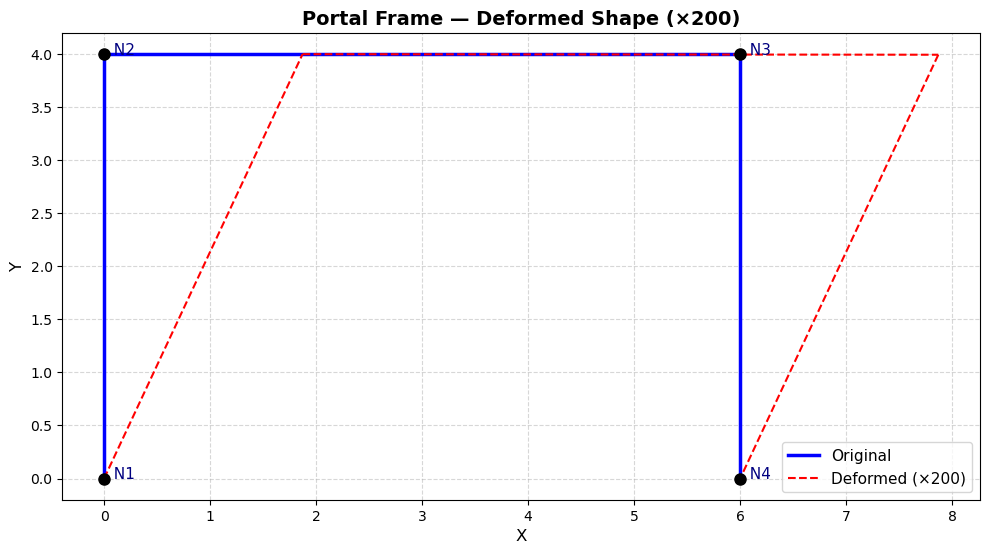

In [9]:
# ── Plot Frame ────────────────────────────────────────────
plot_frame(nodes, elements, U, scale=200, title="Portal Frame — Deformed Shape (×200)")

---
## 9. Try Your Own Frame
Edit the cell below to define your own structure!

Node 2 rotation DOF index = 5
  NODAL DISPLACEMENTS
  Node      u (horiz)       v (vert)        θ (rad)
-------------------------------------------------------
     3       0.000000       0.000000      -0.000425
     2      -0.000052      -0.000260       0.000851
     7       0.000000       0.000000      -0.000421

  REACTION FORCES
  Node             Rx             Ry             Mz
-------------------------------------------------------
     3      -369.1696      1081.4235         0.0000
     7       369.1696     -1081.4235         0.0000

  ELEMENT FORCES (Local Coordinates)

Element 1  (nodes 3→2)
  Axial  N1 =    1081.4235   N2 =   -1081.4235
  Shear  V1 =     369.1696   V2 =    -369.1696
  Moment M1 =       0.0000   M2 =   53160.4289

Element 2  (nodes 2→7)
  Axial  N1 =    -369.1696   N2 =     369.1696
  Shear  V1 =    1081.4235   V2 =   -1081.4235
  Moment M1 =   90839.5711   M2 =       0.0000


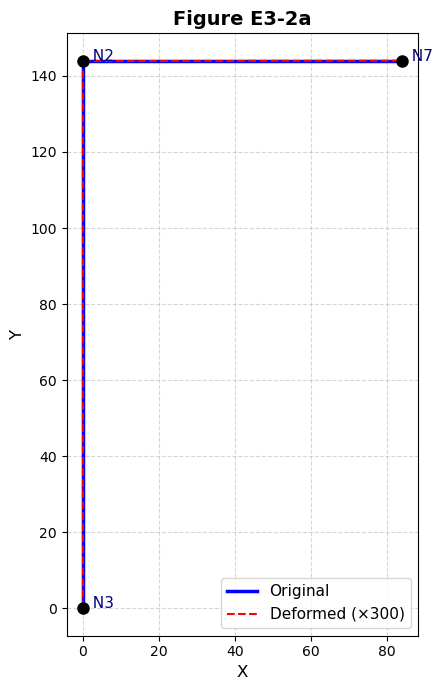

In [10]:
# ── Define your own nodes ─────────────────────────────────
# ── Figure E3-2a ──────────────────────────────────────────
# Units: pounds and inches

my_nodes = {
    3: (0.0,   0.0),    # Base - pinned support
    2: (0.0, 144.0),    # Top of column / left of beam (12ft = 144in)
    7: (84.0, 144.0),   # Right end of beam (7ft = 84in)
}

E = 30e6    # psi  (30 x 10^6)
A = 20.0    # in²
I = 100.0   # in⁴

my_elements = [
    {'nodes': (3, 2), 'E': E, 'A': A, 'I': I},   # Member 1 - column
    {'nodes': (2, 7), 'E': E, 'A': A, 'I': I},   # Member 2 - beam
]

my_bc = {
    3: [True, True, False],   # Pinned at base (no rotation restraint)
    7: [True, True, False],   # Roller at right end
}

n_dof2 = 3 * len(my_nodes)
F2     = np.zeros(n_dof2)

# M = 12 ft-k = 144,000 lb-in applied at Node 2 (DOF index 5 = rotation)
# Node order: 3→index 0, 2→index 1, 7→index 2
# Node 2 DOFs: index 3,4,5
print(f"Node 2 rotation DOF index = {list(my_nodes.keys()).index(2) * 3 + 2}")

F2[5] = 144000   # 12 ft-k moment at Node 2 (12 x 12000 = 144,000 lb-in)

K2      = assemble_global_K(my_nodes, my_elements)
U2, R2  = apply_bc_and_solve(K2, F2, my_bc, my_nodes)
forces2 = compute_element_forces(my_elements, my_nodes, U2)

print_results(my_nodes, my_elements, U2, R2, forces2)
plot_frame(my_nodes, my_elements, U2, scale=300, title="Figure E3-2a")

In [11]:
## Based on the information above, the code has also come to the conclusion that the frame rests in equalibrium. One thing to
## note however is that the moments match the book value, but the forces that the code developed do differ from the book's 
## answer. This can be seen in the value of 1081.42lb and the books 1612lb

---
## 10. HW9 — Hoover Dam Arch Analysis (El. 1800, 400 ft below crest)

**Problem statement:**
1. Create a 2D structural model of the arch
2. Apply fixed-fixed (clamped) boundary conditions at both ends
3. Apply hydrostatic pressure (24,960 psf) as lumped nodal loads
4. Compute crown deflection and compare to Dym & Williams analytical solution
5. Compute axial force, shear, and moment at the crown
6. Compute principal stress magnitudes and directions at the crown

**Parameters:**
- R = 1200.57 ft (upstream arch radius at El. 1800)
- Central angle = 133°
- E = 3000 psi = 432,000 psf (concrete)
- A = 828,572 ft² (arch cross-sectional area from integration)
- I = (1/12) × 1 ft × (347.67 ft)³
- c = 347.67/2 = 173.835 ft (distance from neutral axis to extreme fiber)
- q = 24,960 psf (hydrostatic pressure at 400 ft depth)
- λ = 0.58 (arch rise parameter)
- 8 elements (9 nodes) for good arch approximation

  PARAMETERS
  E         = 3,000 psi  =  432,000 psf
  A         = 828,572 ft²
  I         = 3,502,034.4 ft⁴
  c         = 173.835 ft
  q         = 24,960 psf
  R         = 1200.57 ft
  λ         = 0.58

  NODE COORDINATES
   Node        X (ft)        Y (ft)   Angle (°)
      1     -1100.995       478.726      156.50
      2      -918.004       773.716      139.88
      3      -658.264      1004.020      123.25
      4      -343.491      1150.384      106.62
      5         0.000      1200.570       90.00
      6       343.491      1150.384       73.38
      7       658.264      1004.020       56.75
      8       918.004       773.716       40.12
      9      1100.995       478.726       23.50

  HYDROSTATIC NODAL LOADS
   Node         Fx (lb)         Fy (lb)
      1       3681474.8      -2283723.2
      2       6555667.9      -5525275.5
      3       4700809.5      -7169926.1
      4       2452943.1      -8215139.7
      5            -0.0      -8573532.0
      6      -2452943.1      -

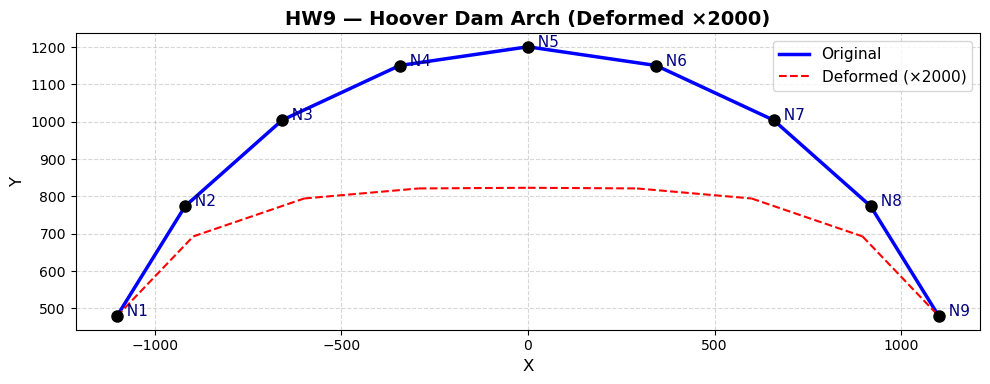

In [12]:
# ════════════════════════════════════════════════════════════════
# HW9 — Hoover Dam Arch Analysis
# Units: feet (ft) and pounds (lb) throughout
# ════════════════════════════════════════════════════════════════

# ── Step 1: Parameters ──────────────────────────────────────────
R           = 1200.57          # ft  — upstream arch radius at El. 1800
total_angle = 133.0            # degrees — central angle of arch
half_angle  = total_angle / 2.0
thickness   = 347.67           # ft  — arch thickness (from integration result)
depth       = 1.0              # ft  — unit depth assumption
c           = thickness / 2.0  # ft  — extreme fiber distance from neutral axis

E_psi       = 3000.0           # psi — concrete elastic modulus
E_psf       = E_psi * 144.0    # psf — converted (1 psi = 144 psf)
A_arch      = 828572.0         # ft² — arch cross-sectional area (from integration)
I_arch      = (1/12) * depth * thickness**3  # ft⁴
lam         = 0.58             # λ  — arch rise parameter (Dym & Williams)
q           = 24960.0          # psf — hydrostatic pressure at 400 ft depth
n_nodes     = 9                # 8 elements for accurate arch approximation

print('='*60)
print('  PARAMETERS')
print('='*60)
print(f'  E         = {E_psi:,.0f} psi  =  {E_psf:,.0f} psf')
print(f'  A         = {A_arch:,.0f} ft²')
print(f'  I         = {I_arch:,.1f} ft⁴')
print(f'  c         = {c:.3f} ft')
print(f'  q         = {q:,.0f} psf')
print(f'  R         = {R:.2f} ft')
print(f'  λ         = {lam}')

# ── Step 2: Node Coordinates Along Arch ─────────────────────────
# Nodes placed at equal angular spacing from left to right abutment
# Crown (Node 5) sits at the top (90°)
node_angles  = np.linspace(90 + half_angle, 90 - half_angle, n_nodes)
arch_nodes   = {i+1: (R * np.cos(np.radians(a)), R * np.sin(np.radians(a)))
                for i, a in enumerate(node_angles)}

print('\n' + '='*60)
print('  NODE COORDINATES')
print('='*60)
print(f"  {'Node':>5}  {'X (ft)':>12}  {'Y (ft)':>12}  {'Angle (°)':>10}")
for nid, (x, y) in arch_nodes.items():
    ang = node_angles[nid-1]
    print(f'  {nid:>5}  {x:>12.3f}  {y:>12.3f}  {ang:>10.2f}')

# ── Step 3: Elements ─────────────────────────────────────────────
arch_elements = [{'nodes': (i+1, i+2), 'E': E_psf, 'A': A_arch, 'I': I_arch}
                 for i in range(n_nodes - 1)]

# ── Step 4: Boundary Conditions — Fixed-Fixed ────────────────────
# Both abutments fully clamped: u=0, v=0, θ=0
arch_bc = {
    1:       [True, True, True],   # Left abutment  — DOFs 1, 2, 3
    n_nodes: [True, True, True],   # Right abutment — DOFs 25, 26, 27
}

# ── Step 5: Hydrostatic Nodal Loads ──────────────────────────────
# Pressure acts radially inward (toward arch center)
# Conversion: pressure (psf) → line load (lb/ft) × tributary length → point load (lb)
# Each node receives load from half of each adjacent element
node_ids   = list(arch_nodes.keys())
n_dof_arch = 3 * n_nodes
F_arch     = np.zeros(n_dof_arch)

# First pass to compute element lengths
_ = assemble_global_K(arch_nodes, arch_elements)

print('\n' + '='*60)
print('  HYDROSTATIC NODAL LOADS')
print('='*60)
print(f"  {'Node':>5}  {'Fx (lb)':>14}  {'Fy (lb)':>14}")

for elem in arch_elements:
    ni, nj   = elem['nodes']
    xi, yi   = arch_nodes[ni]
    xj, yj   = arch_nodes[nj]
    L_e      = elem['L']
    # Inward radial unit vector at element midpoint
    xm       = (xi + xj) / 2.0
    ym       = (yi + yj) / 2.0
    rm       = np.sqrt(xm**2 + ym**2)
    nx_in    = -xm / rm   # inward x-component
    ny_in    = -ym / rm   # inward y-component
    # Tributary nodal force = pressure × half element length
    F_node   = q * L_e / 2.0
    ii = node_ids.index(ni) * 3
    ij = node_ids.index(nj) * 3
    F_arch[ii]   += F_node * nx_in
    F_arch[ii+1] += F_node * ny_in
    F_arch[ij]   += F_node * nx_in
    F_arch[ij+1] += F_node * ny_in

for i, nid in enumerate(node_ids):
    fx = F_arch[3*i]; fy = F_arch[3*i+1]
    print(f'  {nid:>5}  {fx:>14.1f}  {fy:>14.1f}')

# ── Step 6: Assemble & Solve ──────────────────────────────────────
K_arch          = assemble_global_K(arch_nodes, arch_elements)
U_arch, R_arch  = apply_bc_and_solve(K_arch, F_arch, arch_bc, arch_nodes)
forces_arch     = compute_element_forces(arch_elements, arch_nodes, U_arch)

print_results(arch_nodes, arch_elements, U_arch, R_arch, forces_arch)

# ── Step 7: Crown Deflection vs Analytical ───────────────────────
crown_node  = (n_nodes + 1) // 2   # middle node = Node 5
crown_idx   = node_ids.index(crown_node) * 3
u_crown     = U_arch[crown_idx]
v_crown     = U_arch[crown_idx + 1]
w_FEM       = abs(v_crown)   # vertical (radial at crown)

lam2        = lam**2
w_analytical = (lam2/2) / (1 + 4*lam2/15) * (q * R**2 / (E_psf * A_arch))

print('\n' + '='*60)
print('  STEP 4 — CROWN DEFLECTION COMPARISON')
print('='*60)
print(f'  FEM  w^c(0) = {w_FEM:.4f} ft')
print(f'  Analytical  = {w_analytical:.4f} ft   (Dym & Williams, λ={lam})')
print(f'  Difference  = {abs(w_FEM-w_analytical):.4f} ft')
print(f'  % Error     = {abs(w_FEM-w_analytical)/w_analytical*100:.2f}%')

# ── Step 8: Crown Element Forces ─────────────────────────────────
# Use the element just to the left of the crown (element index n_elems//2 - 1)
n_elems         = n_nodes - 1
crown_elem_idx  = n_elems // 2 - 1
crown_elem      = arch_elements[crown_elem_idx]
ni_c, nj_c      = crown_elem['nodes']
ii_c = node_ids.index(ni_c) * 3
ij_c = node_ids.index(nj_c) * 3
dofs_c          = [ii_c, ii_c+1, ii_c+2, ij_c, ij_c+1, ij_c+2]
u_elem_global   = U_arch[dofs_c]
T_c             = transformation_matrix(crown_elem['angle'])
u_local         = T_c @ u_elem_global
k_local_c       = local_stiffness(crown_elem['E'], crown_elem['A'],
                                   crown_elem['I'], crown_elem['L'])
f_local_c       = k_local_c @ u_local

# j-end of this element is the crown node
N_crown = f_local_c[3]   # axial force
V_crown = f_local_c[4]   # shear force
M_crown = f_local_c[5]   # bending moment

print('\n' + '='*60)
print('  STEP 5 — CROWN ELEMENT FORCES')
print('='*60)
print(f'  Element {crown_elem_idx+1}  '
      f'(nodes {ni_c}→{nj_c}, angle={crown_elem["angle"]:.2f}°)')
print(f'  N (axial)  = {N_crown:>15.2f} lb')
print(f'  V (shear)  = {V_crown:>15.2f} lb')
print(f'  M (moment) = {M_crown:>15.2f} lb·ft')

# ── Step 9: Principal Stresses at Crown ──────────────────────────
# From class notes:
#   σ_axial    = N / A          (uniform, from axial force)
#   σ_flexural = M * c / I      (from bending, extreme fiber)
#   σ_x        = σ_axial + σ_flexural
#   τ_xy       = V / A          (average shear stress)
#   σ_y        = 0              (assumed per notes)
#
# Principal stresses via eigenvalue problem:
#   σ = | σ_x   τ_xy |
#       | τ_xy  σ_y  |

sigma_axial    = N_crown / A_arch
sigma_flexural = M_crown * c / I_arch
sigma_x        = sigma_axial + sigma_flexural
tau_xy         = V_crown / A_arch
sigma_y        = 0.0

stress_matrix  = np.array([[sigma_x, tau_xy],
                            [tau_xy,  sigma_y]])
eigenvalues, eigenvectors = np.linalg.eig(stress_matrix)
idx_sort             = np.argsort(eigenvalues)[::-1]
principal_stresses   = eigenvalues[idx_sort]
principal_directions = eigenvectors[:, idx_sort]
angles_principal     = np.degrees(np.arctan2(principal_directions[1],
                                              principal_directions[0]))

print('\n' + '='*60)
print('  STEP 6 — PRINCIPAL STRESSES AT CROWN')
print('='*60)
print(f'  Stress components:')
print(f'    σ_axial    = {sigma_axial:>12.4f} psf  ({sigma_axial/144:.4f} psi)')
print(f'    σ_flexural = {sigma_flexural:>12.4f} psf  ({sigma_flexural/144:.4f} psi)')
print(f'    σ_x        = {sigma_x:>12.4f} psf  ({sigma_x/144:.4f} psi)')
print(f'    τ_xy       = {tau_xy:>12.4f} psf  ({tau_xy/144:.4f} psi)')
print(f'    σ_y        = {sigma_y:>12.4f} psf  (assumed)')
print(f'\n  Stress matrix:')
print(f'    | {sigma_x:>10.4f}  {tau_xy:>10.4f} |')
print(f'    | {tau_xy:>10.4f}  {sigma_y:>10.4f} |')
print(f'\n  Principal stresses (eigenvalue solution):')
print(f'    σ₁ = {principal_stresses[0]:>12.4f} psf  '
      f'({principal_stresses[0]/144:.4f} psi)  '
      f'at θ = {angles_principal[0]:.2f}°')
print(f'    σ₂ = {principal_stresses[1]:>12.4f} psf  '
      f'({principal_stresses[1]/144:.4f} psi)  '
      f'at θ = {angles_principal[1]:.2f}°')

# ── Step 10: Plot Arch ───────────────────────────────────────────
plot_frame(arch_nodes, arch_elements, U_arch, scale=2000,
           title='HW9 — Hoover Dam Arch (Deformed ×2000)')
